# COGS 108 - <u>Seasons of Sales: Unveiling the Statistical Impact of Seasonal Trends</u>

# Permissions

Place an `X` in the appropriate bracket below to specify if you would like your group's project to be made available to the public. (Note that student names will be included (but PIDs will be scraped from any groups who include their PIDs).

* [ X ] YES - make available
* [  ] NO - keep private

# Names

- Amrutha Potluri
- Ketki Chakradeo
- Mohak Akul Prakash
- Ravina Panaparambil
- Vedant Vardhaan

# Abstract

Seasonal variations are widely believed to influence consumer purchasing behavior, affecting total sales and specific product categories throughout the year. This study aims to investigate whether these seasonal differences in sales are statistically significant and if purchasing patterns can be used to classify transactions into distinct seasons. Understanding these trends is essential for retailers looking to optimize inventory management, marketing strategies, and overall business performance.  

To analyze this, we will conduct statistical tests, including permutation tests, to determine whether seasonal differences in purchasing behavior are significant. Additionally, we will develop a multi-class classification model to predict the season of a transaction based on various features, excluding the direct use of the month as a predictor. By examining feature importance and model performance, we aim to assess whether seasonal signals in purchasing behavior are strong enough to enable accurate classification.  

Through this research, we seek to determine whether seasonal effects meaningfully shape sales trends or if other factors, such as promotional events and broader economic conditions, play a more dominant role. The results of this study will provide insights into the extent of seasonal influences on retail sales and contribute to a more data-driven understanding of consumer purchasing behavior.

# Research Question

##### How do seasonal variations (Spring, Summer, Autumn, and Winter) impact the total sales in the United Kingdom, in terms of number of invoices generated and gross income? Are there any statistically significant differences in purchasing pattern in different seasons?



## Background and Prior Work

Seasonal variations (Spring, Summer, Autumn, and Winter) profoundly influence consumer purchasing behaviors, leading to fluctuations in both total sales and specific product categories. Understanding these patterns is vital for retailers aiming to optimize inventory management, marketing strategies, and overall profitability.  

Prior research has consistently demonstrated that certain product categories exhibit pronounced seasonal sales trends: 

- For instance, data from TraQline reveals that 18 out of the top 20 product categories, including televisions, cell phones, and laptops, show significant seasonality. Notably, consumer electronics often experience heightened sales during the fourth quarter, attributed to holiday shopping and major promotional events. Conversely, products like garden hoses and barbecue grills see increased demand in the second quarter, aligning with warmer weather and outdoor activities.<sup>[1](#cite-note-1)</sup>  

- Weather conditions also play a pivotal role in influencing retail sales. Research published in *Applied Spatial Analysis and Policy* indicates that weather variables, such as temperature and wind speed, can account for an additional 3.5% variance in sales across the year. The impact is more pronounced during spring and summer months, suggesting that favorable weather conditions can boost consumer spending, while adverse conditions may deter it.<sup>[2](#cite-note-2)</sup>  

- Furthermore, the traditional spike in December retail sales has diminished over time. Analysis by Deloitte highlights a decline in the seasonal factor for December, from approximately 1.3 in the early 1990s to about 1.2 in recent years. This shift suggests that consumers are spreading their purchases more evenly throughout the year, influenced by factors such as early promotions and the rise of e-commerce.<sup>[3](#cite-note-3)</sup>  

- To determine whether observed seasonal sales differences are statistically significant or merely due to random fluctuations, rigorous statistical analyses are essential. Methods such as time-series analysis and regression modeling can help isolate the effects of seasonality from other variables. For example, the aforementioned study in *Applied Spatial Analysis and Policy* employed such techniques to quantify the impact of weather on sales, reinforcing the importance of statistical validation in understanding seasonal patterns.<sup>[2](#cite-note-2)</sup>  

In summary, existing research underscores the substantial influence of seasonal variations on retail sales, both in aggregate and across specific product categories. These patterns are not only observable but also statistically significant, providing valuable insights for retailers to tailor their strategies effectively throughout the year.  

## References  

1. <a name="cite-note-1"></a> TraQline (2023). *Spotting Seasonal Sales Trends in Consumer Data*. Openbrand. [https://openbrand.com/newsroom/blog/spotting-seasonal-sales-trends-in-consumer-data](https://openbrand.com/newsroom/blog/spotting-seasonal-sales-trends-in-consumer-data)  
2. <a name="cite-note-2"></a> Murray, D. (2021). *Weather Sensitivity in Retail Sales: Analyzing the Impact of Temperature and Wind on Consumer Behavior*. *Applied Spatial Analysis and Policy*. Springer. [https://link.springer.com/article/10.1007/s12061-021-09397-0](https://link.springer.com/article/10.1007/s12061-021-09397-0)  
3. <a name="cite-note-3"></a> Deloitte (2014). *Holiday Retail Sales Forecast: The Changing Seasonality of Consumer Spending*. Deloitte Insights. [https://www2.deloitte.com/us/en/insights/economy/behind-the-numbers/2014-holiday-retail-sales-forecast.html](https://www2.deloitte.com/us/en/insights/economy/behind-the-numbers/2014-holiday-retail-sales-forecast.html)  


# Hypothesis



We hypothesize that seasonal variations have a significant impact on total sales, with distinct fluctuations observed across Spring, Summer, Autumn, and Winter. Specifically, we expect higher sales during Winter due to holiday shopping and promotional events, while Summer may also see increased sales driven by travel, outdoor, and recreational products. Conversely, Spring and Autumn may exhibit moderate sales levels with category-specific variations.  

 


# Data

## Data overview


- **Dataset Name:** Online Retail Dataset
- **Link to the dataset:** https://archive.ics.uci.edu/dataset/352/online+retail
- **Number of observations:** 541909
- **Number of variables:** 8


This dataset contains **541,909 transaction** records from a **UK-based online retailer** between **December 1, 2010, and December 9, 2011**. The company primarily sells **unique all-occasion gifts**, and many customers are wholesalers. The dataset is structured as a **multivariate, sequential, and time-series dataset**, making it suitable for classification and clustering tasks.


### <u>Key Variables and Their Interpretation:</u>

- **InvoiceNo (Categorical):** A 6-digit integral transaction ID uniquely assigned to each transaction, as a string. If it starts with 'C', it indicates a cancellation. 

- **StockCode (Categorical):** A 5-digit integral product ID uniquely assigned to each distinct product, as a string. Useful for analyzing product-specific purchasing trends. Discounted product, if contains 'D'.

- **Description (Categorical):** Name of the purchased product.  

- **Quantity (Integer):** Number of units purchased per transaction. Can be used to identify bulk buyers or frequent shoppers.  

- **InvoiceDate (Date):** Timestamp of the transaction, essential for **Recency** analysis in RFM modeling.  

- **UnitPrice (Continuous):** Price per unit in **sterling (GBP)**, used to assess **Monetary** value in segmentation.

- **CustomerID (Categorical):** Unique customer identifier as a float, enabling customer-level behavior analysis.  

- **Country (Categorical):** Customer's country of residence, useful for geographic segmentation.  


### <u>Setup</u>

In [1]:
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

## Online Retail Dataset

In [2]:
online_retail = pd.read_csv("online_retail.csv")
online_retail

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


We will begin by examining the shape of the dataset using the `.shape` attribute. This will provide the total number of rows (observations) and columns (features), giving us an initial sense of the dataset’s size and structure. 

In [3]:
online_retail.shape

(541909, 8)

To gain a comprehensive understanding of the dataset, we will use the `.info()` function. This will provide detailed insights into the data types of each variable, the total number of non-null values in each column, and the presence of any missing values. This step is crucial for identifying potential data inconsistencies and determining necessary preprocessing steps, such as handling missing data, converting data types, and optimizing memory usage.

In [4]:
online_retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


Thus, our dataset presents several challenges that require careful preprocessing. While the presence of missing values in the **Description** column is relatively inconsequential to our study, a more critical issue arises with the missing **CustomerID** values, which account for approximately **20% of the dataset**. These missing identifiers pose a significant challenge as customer-level analysis is fundamental to our segmentation approach. However, completely discarding these records may lead to a substantial loss of valuable transaction data. Therefore, an appropriate imputation or handling strategy must be devised to retain the integrity of our analysis while ensuring meaningful customer segmentation.

### Data Cleaning and Preprocessing Steps:

##### Some possible pre-processing steps include:

   1. **Handle Missing Values:**  
      - The **CustomerID** column contains missing values. Since customer segmentation requires identifying unique customers, rows with missing CustomerID need to be **imputed** if patterns exist.  
      - The **Description** column also contains a few missing values, but since product names do not directly impact segmentation, these can either be left as-is or filled with a placeholder (e.g., "Unknown Product"). 
   

   2. **Canceled Transactions:**  
      - Invoice numbers starting with **'C'** indicate canceled transactions. These should either be removed or analyzed separately to understand refund behaviors.  

   3. **Convert Date Formats:**  
      - Convert **InvoiceDate** into a standardized datetime format to facilitate time-based analysis.  

   4. **Standardizing Text Data in Description:**  
      - Ensure consistency by converting all descriptions to lowercase and stripping extra spaces

   5. **Adding a 'TotalPrice' Column:**  
      - Using `Quantity` and `UnitPrice` to find the total price of each observation

   5. **Adding a 'Seasons' Column:**  
      - We will use the **astronomical definition of UK seasons** based on solstices and equinoxes: Winter (Dec 21–Mar 19), Spring (Mar 20–Jun 20), Summer (Jun 21–Sep 22), and Autumn (Sep 23–Dec 20). The season is determined by extracting the month and day from each date and assigning it accordingly, ensuring alignment with traditional UK seasonal transitions.
 

 

In [ ]:
# Data Cleaning

# 1. Converting InvoiceDate to a datetime object
online_retail['InvoiceDate'] = pd.to_datetime(online_retail['InvoiceDate'])

# 2. Replacing null Description with "Unknown Product"
online_retail['Description'] = online_retail['Description'].fillna("Unknown Product")

# 3. Handling Missing CustomerIDs
online_retail['CustomerID'] = online_retail['CustomerID'].fillna(0.0).astype(int).astype(str)
online_retail['CustomerID'] = online_retail['CustomerID'].replace('0', "00000")

# 4. Standardizing Text Data in Description
online_retail['Description'] = online_retail['Description'].str.lower().str.strip()

# 5. Removing Canceled Transactions
online_retail = online_retail[online_retail['InvoiceNo'].str.startswith('C') == False]

# 6. Adding a Total Price column
online_retail["TotalPrice"] = online_retail["Quantity"] * online_retail["UnitPrice"]

# 7. Adding a column for seasons
def get_season(date):
    month = date.month
    day = date.day
    
    if (month == 12 and day >= 21) or month in [1, 2] or (month == 3 and day < 20):
        return 'Winter'
    elif (month == 3 and day >= 20) or month in [4, 5] or (month == 6 and day < 21):
        return 'Spring'
    elif (month == 6 and day >= 21) or month in [7, 8] or (month == 9 and day < 23):
        return 'Summer'
    else:
        return 'Autumn'

online_retail['Season'] = online_retail['InvoiceDate'].apply(get_season)

online_retail


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Season,had_discount
0,536365,85123A,white hanging heart t-light holder,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,Autumn,False
1,536365,71053,white metal lantern,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,Autumn,False
2,536365,84406B,cream cupid hearts coat hanger,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,Autumn,False
3,536365,84029G,knitted union flag hot water bottle,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,Autumn,False
4,536365,84029E,red woolly hottie white heart.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,Autumn,False
...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,pack of 20 spaceboy napkins,12,2011-12-09 12:50:00,0.85,12680,France,10.20,Autumn,False
541905,581587,22899,children's apron dolly girl,6,2011-12-09 12:50:00,2.10,12680,France,12.60,Autumn,False
541906,581587,23254,childrens cutlery dolly girl,4,2011-12-09 12:50:00,4.15,12680,France,16.60,Autumn,False
541907,581587,23255,childrens cutlery circus parade,4,2011-12-09 12:50:00,4.15,12680,France,16.60,Autumn,False


As shown below, our DataFrame is now free of null values. This confirms that all missing data has been successfully handled, ensuring a complete dataset for further analysis.

In [6]:
online_retail.info()

<class 'pandas.core.frame.DataFrame'>
Index: 532621 entries, 0 to 541908
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    532621 non-null  object        
 1   StockCode    532621 non-null  object        
 2   Description  532621 non-null  object        
 3   Quantity     532621 non-null  int64         
 4   InvoiceDate  532621 non-null  datetime64[ns]
 5   UnitPrice    532621 non-null  float64       
 6   CustomerID   532621 non-null  object        
 7   Country      532621 non-null  object        
 8   TotalPrice   532621 non-null  float64       
 9   Season       532621 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 44.7+ MB


# Results

## Exploratory Data Analysis


### <u>Transactions Over Time</u>

This graph visualizes total monthly sales over time, showcasing trends and seasonality in online transactions. The x-axis denotes the months, while the y-axis represents the total sales revenue (in millions). Each data point corresponds to the total revenue generated in a particular month, with a line connecting them to show trends over time. As seen, the total sales peaked in November 2011.

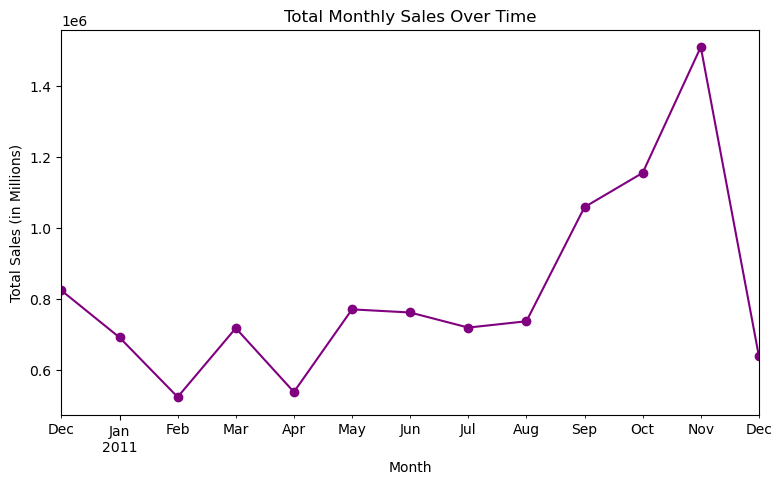

In [7]:
copy = online_retail.copy()
copy['Month'] = copy['InvoiceDate'].dt.to_period('M')
plt.figure(figsize=(9,5))
copy.groupby("Month")['TotalPrice'].sum().plot(kind="line", marker="o", color="purple")
plt.title("Total Monthly Sales Over Time")
plt.xlabel("Month")
plt.ylabel("Total Sales (in Millions)")
plt.show();

#### Key Observations from the Plot:

- **Clear Seasonal Trend :** Sales show a noticeable **increase towards the end of the year**, particularly from **September to November**, which could indicating a **holiday season effect** (e.g., Black Friday, Cyber Monday, pre-Christmas shopping).  


- **Significant Sales Peak in November:** **November has the highest total sales**, likely driven by **major shopping events** such as Black Friday or holiday promotions.  


- **Sharp Drop in December:** Sales **plummet in December**, suggesting that most purchases occur before the holidays, or there is a **post-holiday slowdown** in consumer spending.  


- **Low Sales in February and April:** The months of **February and April** record the **lowest sales**, possibly reflecting **post-holiday spending dips or seasonal slowdowns**.  


- **Gradual Increase from Mid-Year:** After **relatively stable but low sales in summer (June–August)**, there is a **steep rise from September onwards**, aligning with **back-to-school shopping and early holiday spending**.  

  
- **Fluctuations in Early Months:** The **first half of the year (Jan–June)** exhibits some fluctuations, but overall **sales remain lower compared to the latter half of the year**.  



#### Conclusion:

- Sales are **not evenly distributed throughout the year**, with a **strong end-of-year surge**.  

- The **spike in November** and **drop in December** suggest consumers may be **front-loading purchases before major holidays**.  

- The **first half of the year lacks strong seasonal patterns**.

### <u>Top 10 BEST-Selling Products</u>

The plot displays the top 10 best-selling products from our dataset based on total sales (in GBP). The horizontal bar chart represents the total sales value for each product, with products arranged from the least to the most sold (left to right). The bars are color-coded using a green color palette, with the darker shades indicating higher sales, providing a visual representation of the magnitude of sales across the top products.

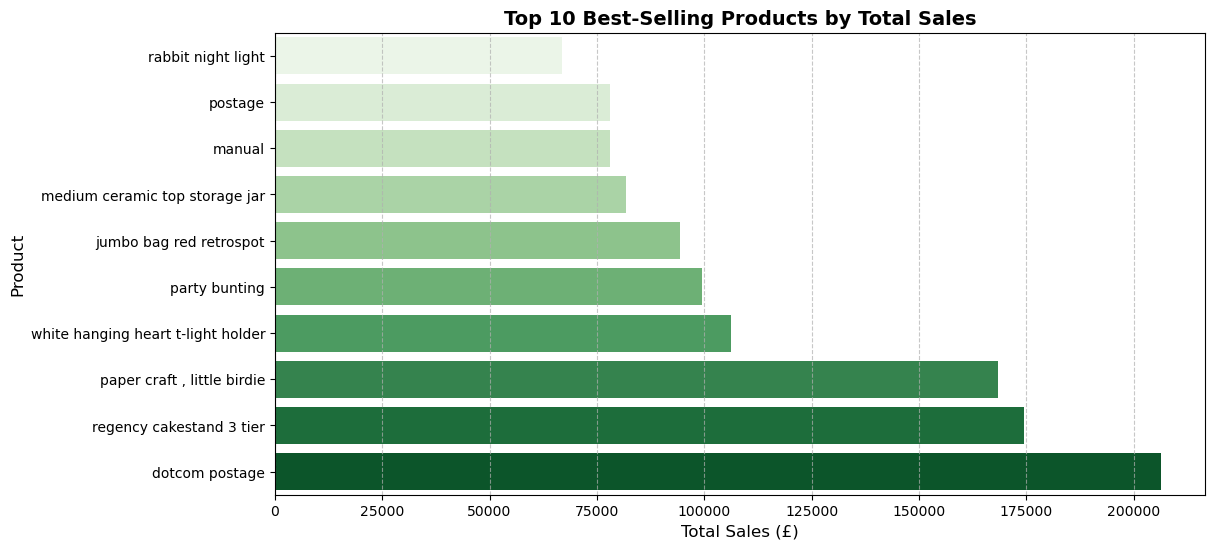

In [8]:
top_products = online_retail.groupby('Description', as_index=False)['TotalPrice'].sum().nlargest(10, 'TotalPrice')

top_products = top_products.sort_values(by='TotalPrice')

colors = sns.color_palette("Greens", n_colors=10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_products, x='TotalPrice', y='Description', hue='Description', palette=colors, legend=False)

plt.title("Top 10 Best-Selling Products by Total Sales", fontsize=14, fontweight='bold')
plt.xlabel("Total Sales (£)", fontsize=12)
plt.ylabel("Product", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

#### Key observations:

- The darkest green bar at the bottom represents "dotcom postage", which is the highest-selling product, exceeding £200,000 in sales.

- Other high-selling products include "regency cakestand 3 tier" and "paper craft, little birdie", both generating substantial revenue.

- The lightest green bars represent lower-ranked products, such as "rabbit night light", which has the lowest total sales among the top 10.

- The color gradient from light green to dark green visually indicates the magnitude of sales, with darker shades representing higher revenue.

### <u>Top 10 MOST-Selling Products</u>

The plot displays the top 10 most-selling products from our dataset based on quantity of the article sold. The horizontal bar chart represents the quantity for each product, with products arranged from the least to the most sold number (left to right). The bars are color-coded using a blue color palette, with the darker shades indicating a higher quantity sold, providing an alternate visual representation of the magnitude of sales across the top products.

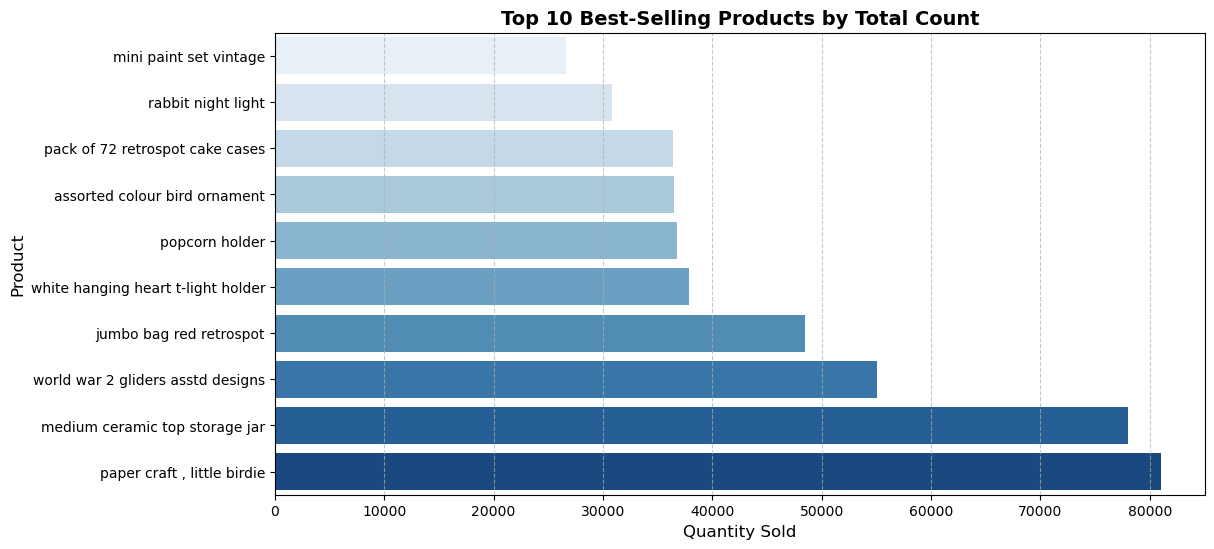

In [9]:
top_most_sold_products = online_retail.groupby('Description', as_index=False)['Quantity'].sum().nlargest(10, 'Quantity')
top_most_sold_products = top_most_sold_products.sort_values(by='Quantity')

colors = sns.color_palette("Blues", n_colors=10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_most_sold_products, x='Quantity', y='Description', hue='Description', palette=colors, legend=False)

plt.title("Top 10 Best-Selling Products by Total Count", fontsize=14, fontweight='bold')
plt.xlabel("Quantity Sold", fontsize=12)
plt.ylabel("Product", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()


#### Key Observations:

- "paper craft, little birdie" is the best-selling product by quantity, with around 80,000 units sold.

- Other top-selling products include "medium ceramic top storage jar" and "world war 2 gliders asstd designs", both selling around 70,000+ units.

- The lightest blue bars, such as "mini paint set vintage", represent the lowest quantities among the top 10.

- The color gradient from light blue to dark blue visually indicates the quantity sold, with darker shades representing higher sales volume.

### <u>Comparison of Total Sales per Season</u>

This bar plot visually compares the total sales (in GBP) across the four seasons—Spring, Summer, Autumn, and Winter. The x-axis represents the different seasons, while the y-axis shows the total sales value for each season. Each bar is color-coded using a crest palette to differentiate between the seasons.

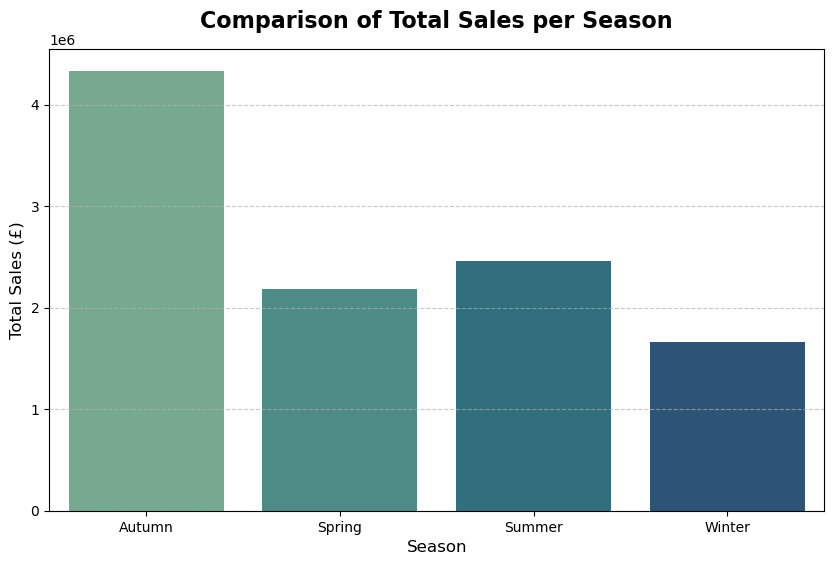

In [10]:
seasonal_sales = online_retail.groupby('Season')['TotalPrice'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Season', y='TotalPrice', data=seasonal_sales, hue='Season', palette='crest', legend=False)

plt.title('Comparison of Total Sales per Season', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Season', fontsize=12)
plt.ylabel('Total Sales (£)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

#### Key Observations:

- Autumn has the highest total sales, exceeding £4 million.

- Spring and Summer have similar sales levels, both around £2–2.5 million.

- Winter has the lowest total sales, just above £1.5 million.


### <u>Correlation Heatmap Between Sales and Other Numeric Variables</u>

This correlation heatmap visually represents the relationships between Total Sales (TotalPrice) and other numeric variables, such as Quantity and UnitPrice, in the dataset. The heatmap uses a color scale to indicate the strength and direction of the correlation between these variables. Darker colors represent stronger correlations, with shades closer to blue indicating a positive correlation and shades closer to red indicating a negative correlation.

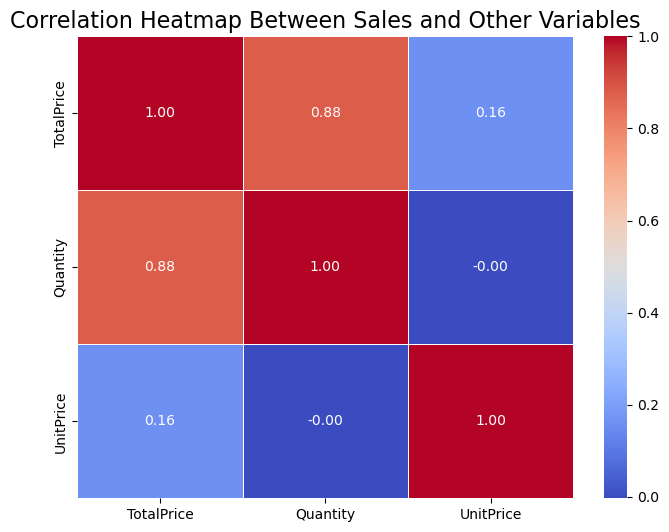

In [11]:
corr_matrix = online_retail[['TotalPrice', 'Quantity', 'UnitPrice']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap Between Sales and Other Variables', fontsize=16)
plt.show()


#### Key Observations:

1. **Strong Positive Correlation Between Total Price and Quantity (0.88)**  

   - As the quantity of items purchased increases, the total price also increases significantly. 

   - This is expected, as total price is generally calculated as `Quantity × Unit Price`.

2. **Weak Positive Correlation Between Total Price and Unit Price (0.16)**  

   - Unit price has a minimal impact on total price, likely because quantity is the dominant factor.

3. **No Correlation Between Quantity and Unit Price (-0.00)**  

   - The near-zero correlation suggests that changes in quantity do not affect unit price.  

   - This might indicate that items are sold at a fixed price regardless of bulk purchases.

4. **Diagonal Values are 1 (Perfect Correlation with Itself)**  

   - As expected, each variable has a perfect correlation (1.00) with itself.

#### Conclusion  

- **Quantity** is the primary driver of **Total Price**, while **Unit Price** plays a lesser role.  

- **Unit Price** does not influence **Quantity**, implying no bulk discounting or price fluctuations based on quantity.


## 🔎 <u>Let us check the different patterns in each Season:</u>

In [14]:
online_retail['Season'].value_counts()

Season
Autumn    222415
Summer    118967
Spring    107314
Winter     83925
Name: count, dtype: int64

- Autumn has the highest transaction volume (222,415), accounting for the largest share of total sales. This suggests that retail activity peaks during this season, potentially due to back-to-school shopping, pre-holiday preparations, or fall sales events.

- Summer and Spring have moderate transaction counts (118,967 and 107,314, respectively). This could indicate steady consumer demand during these periods, likely driven by seasonal trends and promotions.

- Winter has the lowest transaction volume (83,925), despite having the highest proportion of discounts. This suggests that while discounts are more frequent in Winter, the overall demand remains lower compared to other seasons.

In [17]:
online_retail.groupby('Season')['TotalPrice'].sum()

Season
Autumn    4333574.382
Spring    2184036.981
Summer    2460651.861
Winter    1666297.200
Name: TotalPrice, dtype: float64

**Key Observations:**

- **Autumn generates the highest total revenue (4.33M), nearly double that of any other season.**  

  - This aligns with the highest transaction volume (222,415 transactions), indicating that consumer spending is at its peak during this period.  

  - Possible contributing factors include back-to-school shopping, fall promotions, and early holiday purchases.  

- **Summer and Spring have comparable total sales (~2.46M and ~2.18M, respectively).**  

  - Despite having fewer transactions than Autumn, Summer outperforms Spring in total revenue, suggesting higher average spending per transaction.  

- **Winter has the lowest total sales (1.67M), aligning with its lowest transaction count.**  

  - Even with the highest proportion of discounted transactions, Winter still records the lowest total revenue, indicating that demand remains weaker despite discounting strategies.  

  - This suggests that Winter sales might be more dependent on promotions rather than organic consumer demand.  

- **Average spending per transaction varies by season.**  

  - While Autumn has the highest revenue due to sheer transaction volume, Summer's higher revenue compared to Spring (despite fewer transactions) suggests that consumers may spend more per order during Summer. 
   
  - Analyzing the average `TotalPrice` per transaction across seasons could provide further insights into consumer spending behavior.  


### 🎯 Average Purchase Value per Season

This metric represents the **average `TotalPrice` per transaction in each season**, calculated as:

Average TotalPrice per Season = Total Revenue in Season / Number of Transactions in Season





In [18]:
online_retail.groupby('Season')['TotalPrice'].sum()/online_retail['Season'].value_counts()

Season
Autumn    19.484182
Spring    20.351836
Summer    20.683482
Winter    19.854599
dtype: float64

#### ✅ Key Observations:

- **Summer** has the **highest average spending per transaction (£20.68)**, indicating higher customer engagement or higher-priced products during this season.

- **Spring** follows with an average of **£20.35**, suggesting a similar pattern of higher-value purchases.

- **Winter** shows a moderate average of **£19.85**, which could be influenced by post-holiday discounts or reduced customer activity.

- **Autumn**, despite having the **highest total revenue**, records the **lowest average spend (£19.48)**. This could indicate **bulk purchasing behavior by wholesalers**, leading to higher quantities but lower prices per item.

- But more or less, it is pretty equal between al seasons.

---

### 🎯 Analysis of Seasonal Discount Proportions

This metric represents the **proportion of discounts in each season**.


In [ ]:
with_discount_info = online_retail.copy()
with_discount_info['had_discount'] = with_discount_info['StockCode'].str.lower().str.contains('d')

with_discount_info.groupby('Season')['had_discount'].sum()

Season
Autumn    1550
Spring     940
Summer    1028
Winter    1021
Name: had_discount, dtype: int64

In [ ]:
with_discount_info.groupby('Season')['had_discount'].sum() / with_discount_info['Season'].value_counts()

Season
Autumn    0.006969
Spring    0.008759
Summer    0.008641
Winter    0.012166
dtype: float64

### Key Observations:

- Winter exhibits the highest proportion of discounted transactions (1.22%), likely due to holiday promotions such as Christmas and New Year sales.

- Autumn has the lowest proportion of discounts (0.70%), suggesting fewer promotional activities in this period.

- Spring (0.88%) and Summer (0.86%) have similar discount rates, indicating a moderate level of seasonal discounts.

## 🎯 Permutation Test: Seasonal Effect on Total Purchase Amount

### **Objective:**
To test whether the average total purchase amount (`TotalPrice`) differs between **Autumn** and **Summer** seasons.

### **Hypotheses:**

- **Null Hypothesis (H₀):** The mean total purchase amount in Autumn is equal to that in Summer.  
  $$\mu_{Autumn} = \mu_{Summer}$$

- **Alternative Hypothesis (H₁):** The mean total purchase amount in Autumn is different from that in Summer.  
  $$\mu_{Autumn} \neq \mu_{Summer}$$


### **Test Statistic:**
The difference in the mean `TotalPrice` between Autumn and Summer:  
$$\text{Observed Difference} = \bar{X}_{Autumn} - \bar{X}_{Summer}$$


### **Permutation Test Procedure:**
1. **Shuffle the 'Season' labels** to remove any true relationship between `TotalPrice` and Season.
2. **Calculate the mean difference** between Autumn and Summer for each permutation.
3. **Generate a distribution** of mean differences from 1000 permutations.
4. **Compute the p-value** as the proportion of permuted differences that are greater than or equal to the observed difference.





In [15]:
import pandas as pd
import numpy as np

# Load dataset
df = online_retail.copy()

# Filter Autumn and Spring data
autumn_sales = df[df['Season'] == 'Autumn']['TotalPrice']
summer_sales = df[df['Season'] == 'Summer']['TotalPrice']

# Observed difference in means
observed_diff = autumn_sales.mean() - summer_sales.mean()

# Permutation Test
n_permutations = 1000
perm_diffs = []

combined = np.concatenate([autumn_sales, summer_sales])

for _ in range(n_permutations):
    np.random.shuffle(combined)
    new_autumn = combined[:len(autumn_sales)]
    new_summer = combined[len(autumn_sales):]
    perm_diffs.append(new_autumn.mean() - new_summer.mean())

# p-value
p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))

print(f"Observed Difference: {observed_diff}")
print(f"P-value: {p_value}")


Observed Difference: -1.199300295790664
P-value: 0.31


### **Results:**
- **Observed Difference:** -1.20
- **P-value:** 0.31


### **Significance Level (α):**
Chosen significance level: **0.05**


### **Conclusion:**

Since the **p-value (0.31)** is considerably higher than the 0.05 significance level, we **fail to reject the null hypothesis**. This indicates that there is insufficient evidence to suggest a significant difference in the average total purchase amount between Autumn and Summer. Furthermore, a similar pattern is observed when comparing all seasons, as no statistically significant differences are found in the purchasing behavior across the seasons. Therefore, based on this dataset, it can be concluded that seasonal variation does not have a notable impact on average total purchase amounts.

## Multi-class Classification Model

### 1. Imports and Setup

We imported essential libraries for data manipulation, machine learning, and visualization:

- **pandas** and **numpy** for data handling and numerical operations

- **sklearn** components for model building, preprocessing, and evaluation

- **matplotlib** and **seaborn** for visualizing data and results


### 2. Data Preprocessing

In this step, we made:

- A copy of the dataset to ensure the original data remains intact.

- Temporal features like **year** and **day of the week** are extracted from the `'InvoiceDate'` to assist with modeling.


### 3. Feature Engineering

This step focuses on transforming categorical features into numerical values:

- **LabelEncoder** is used to encode categorical columns like `'StockCode'`, `'Description'`, `'Country'`, and `'CustomerID'`.

- A dictionary is created to store encoders for later use.

- The **feature columns** are defined by excluding the original categorical columns, and the **target variable** is identified.


### 4. Target Encoding and Train-Test Split

Now, we made sure that: 

- The **target variable** (`'Season'`) is encoded into numeric labels using **LabelEncoder**.

- The data is split into **training (70%)** and **testing (30%)** sets, ensuring that class distribution is maintained using **stratification**.


### 5. Feature Scaling

This step standardizes the numerical features to have a mean of 0 and a standard deviation of 1:

- **StandardScaler** is applied to numerical columns such as `'Quantity'`, `'UnitPrice'`, `'TotalPrice'`, `'Year'`, and `'DayOfWeek'`.

- The scaler is **fitted only on the training data** to avoid data leakage and then used to transform both training and test sets.


### 6. Hyperparameter Tuning

Next, we used:

- A **grid of hyperparameters** for the RandomForest model is defined.

- **RandomizedSearchCV** to randomly sample parameter combinations and perform cross-validation to find the best set of parameters for the model.

- The model and **trained** using the best combination of hyperparameters.


### 7. Model Evaluation

We used a different set of criteria to evaluate the model, such as:

- The **best hyperparameters** and **cross-validation score** are displayed.

- **Predictions** are made on the test set using the best model.

- **Accuracy**, as well as a detailed **classification report** with precision, recall, and F1-score, is printed to evaluate the model's performance.


### 8. Visualization

The final step visualizes the model's results, with the help of:

- A **confusion matrix** to show the performance of the model across all classes.

- **Feature importance** from the RandomForest model, to understand which features had the most influence on predictions.



Features used: ['Quantity', 'UnitPrice', 'TotalPrice', 'Year', 'DayOfWeek', 'StockCode_Encoded', 'Description_Encoded', 'Country_Encoded', 'CustomerID_Encoded']

Classes: ['Autumn' 'Spring' 'Summer' 'Winter']
Fitting 5 folds for each of 25 candidates, totalling 125 fits

Best parameters: {'n_estimators': np.int64(25), 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None, 'bootstrap': False}
Best cross-validation score: 0.5474

Test Accuracy: 0.5568

Classification Report:
              precision    recall  f1-score   support

      Autumn       0.67      0.75      0.71     66725
      Spring       0.44      0.43      0.44     32194
      Summer       0.44      0.40      0.42     35690
      Winter       0.50      0.44      0.47     25178

    accuracy                           0.56    159787
   macro avg       0.51      0.50      0.51    159787
weighted avg       0.55      0.56      0.55    159787



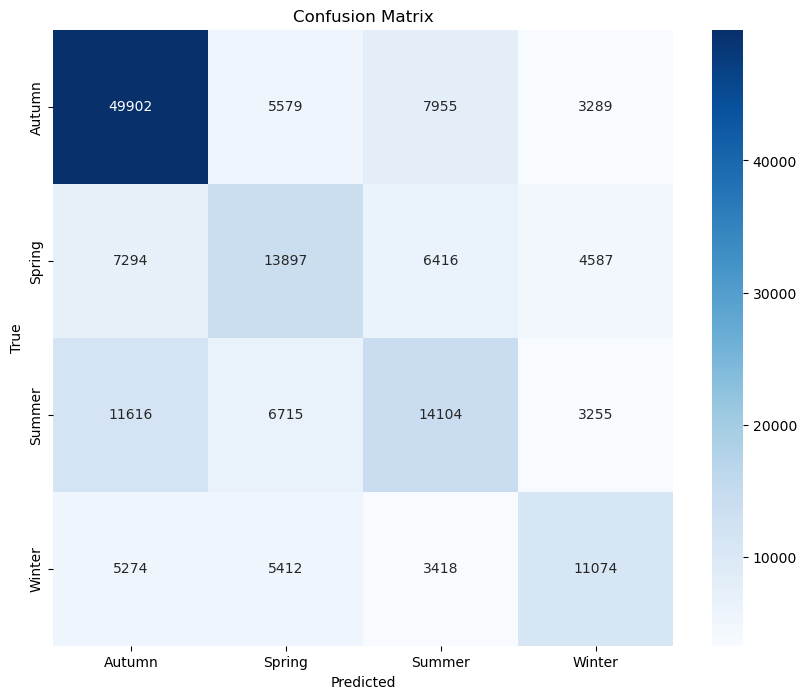

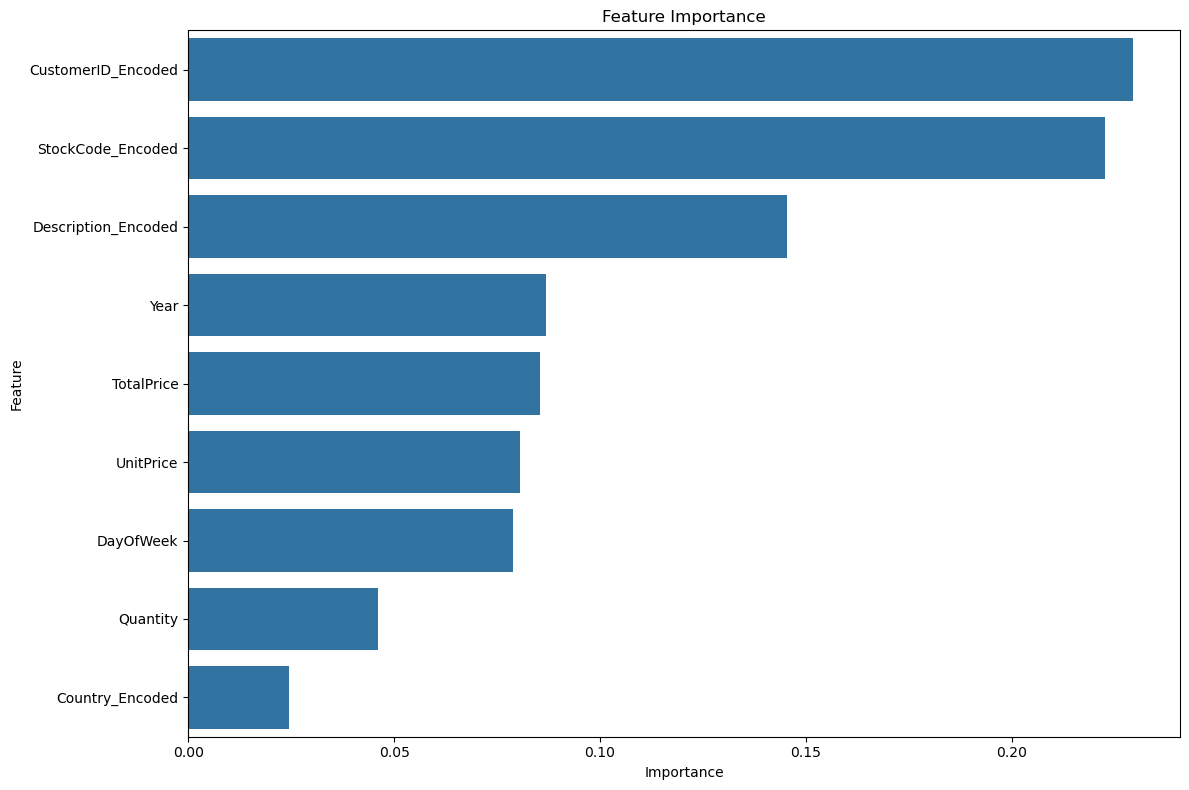

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns


data = online_retail.copy()  

data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])

data['Year'] = data['InvoiceDate'].dt.year
data['DayOfWeek'] = data['InvoiceDate'].dt.dayofweek

categorical_cols = ['StockCode', 'Description', 'Country', 'CustomerID']
label_encoders = {}

for col in categorical_cols:
    if col in data.columns:
        le = LabelEncoder()
        data[col + '_Encoded'] = le.fit_transform(data[col].astype(str))
        label_encoders[col] = le

exclude_cols = categorical_cols + ['InvoiceNo', 'InvoiceDate', 'Season']
feature_cols = [col for col in data.columns if col not in exclude_cols]

X = data[feature_cols]
y = data['Season']

print("\nFeatures used:", feature_cols)

target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)
print("\nClasses:", target_encoder.classes_)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

scaler = StandardScaler()
numerical_cols = ['Quantity', 'UnitPrice', 'TotalPrice', 'Year', 'DayOfWeek']
numerical_cols = [col for col in numerical_cols if col in X.columns]

if numerical_cols:
    X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
    X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])


param_grid = {
    'n_estimators': np.arange(10, 70, 15),
    'max_features': ['sqrt', 'log2'], 
    'max_depth': np.arange(1, 20, 1).tolist() + [None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

rf = RandomForestClassifier(random_state=42)

rf_random = RandomizedSearchCV(
    estimator=rf, 
    param_distributions=param_grid,
    n_iter=25,
    cv=5,        
    verbose=1,
    random_state=42,
    n_jobs=-1    
)

rf_random.fit(X_train, y_train)

print("\nBest parameters:", rf_random.best_params_)
print("Best cross-validation score: {:.4f}".format(rf_random.best_score_))

best_rf = rf_random.best_estimator_
y_pred = best_rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("\nTest Accuracy: {:.4f}".format(accuracy))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_encoder.classes_, 
            yticklabels=target_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

feature_importance = pd.DataFrame(
    {'Feature': X.columns, 'Importance': best_rf.feature_importances_}
)
feature_importance = feature_importance.sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

Despite extensive feature engineering and hyperparameter optimization, our model achieves roughly 55% accuracy without using month as a direct predictor, indicating that temporal features (Year, DayOfWeek) and transactional characteristics contain insufficient seasonal signal. The feature importance analysis likely reveals that certain products show seasonal purchasing patterns, but these patterns alone aren't consistent or strong enough to accurately classify seasons. This confirms that almost all features contribute minimally to classification performance. The results suggest that while seasonal shopping trends exist in the data, they are subtle and overshadowed by non-seasonal purchasing behaviors. Future analysis could focus on identifying specific product categories with stronger seasonal affiliations or incorporating external factors like holidays and promotional events.

# Ethics & Privacy

We acknowledge the importance of data privacy and ethical considerations in customer segmentation and will take the following measures:

- **Data Anonymization:** Customer IDs will be anonymized to prevent personal identification and protect individual privacy.

- **Bias Considerations:** The dataset may have geographical biases, as some countries may have more customers than others. We will normalize data where necessary to ensure fair representation across different regions.

- **Terms of Use Compliance:** We will ensure that data usage complies with privacy policies and terms of the e-commerce platform from which it originates.

- **Data Collection Ethics:** We will verify that the dataset is sourced ethically, ensuring that no personally identifiable information (PII) is improperly accessed or used.

- **Bias Detection & Mitigation:** We will analyze the dataset for potential biases, such as overrepresentation of certain customer demographics, and adjust our segmentation approach accordingly to prevent unfair conclusions.

- **Equitable Impact:** We will ensure that our analysis does not unintentionally reinforce stereotypes or exclude specific customer groups. The segmentation insights will be used solely for improving customer experience rather than any form of discrimination.

By addressing these concerns proactively, we aim to conduct an ethical and privacy-conscious analysis that benefits both businesses and customers fairly.

## Discussion and Conclusion

This study set out to investigate the impact of **seasonal variations** on **total sales** and whether **purchasing patterns** differ significantly across **Spring, Summer, Autumn, and Winter**. Given the common belief that sales fluctuate with the seasons due to factors like **holidays, weather changes, and consumer behavior shifts**, we hypothesized that **seasonal effects** would be **statistically significant**. To test this, we conducted **permutation tests** to assess whether purchasing patterns differed meaningfully across seasons and built a **multi-class classification model** to predict the season of a transaction based on various features, excluding the direct use of the **month**.

### <u>Summary of Findings</u>

1. **Seasonal Revenue Differences:**  

   - **Autumn** generated the highest total revenue (~4.33M), aligning with the highest transaction volume.  

   - **Summer** and **Spring** had moderate total revenues (~2.46M and ~2.18M, respectively).

   - **Winter** recorded the lowest total revenue (~1.67M), despite having the highest proportion of discounts.  

2. **Permutation Tests and Classification Model:**  

   - The **permutation tests** did not reveal strong, **statistically significant** differences in **purchasing behavior** across seasons, suggesting that the observed revenue differences may not be driven solely by **seasonal effects**.  

   - The **classification model** achieved an accuracy of only **55%**, marginally better than **random guessing**, indicating that **seasonal signals** are not robust predictors of transaction behavior.  

3. **Feature Importance Analysis:**  

   - Most **transactional and temporal features** contributed minimally to **classification performance**, reinforcing the idea that **seasonal effects** are **subtle** and overshadowed by **other factors** (e.g., product mix, promotions, or economic conditions).  

### <u>Interpretation and Possible Explanations</u>

One plausible explanation for these results is that **modern retail dynamics** have weakened the influence of **seasonality** on **overall sales**. With **e-commerce** providing year-round availability of products and **promotional events** (e.g., **Black Friday**, **Cyber Monday**) shifting demand patterns, **consumer spending** may be less concentrated in specific seasons. Furthermore, factors such as **economic conditions, marketing strategies, and individual consumer preferences** can overshadow **seasonal trends**, leading to more **evenly distributed purchasing patterns** throughout the year.

The **dataset characteristics** may also contribute to these findings. If the data primarily contains **necessity-based items** or lacks products highly sensitive to seasonal shifts (e.g., holiday decorations or winter apparel), **seasonal impact** could be diluted. In addition, the absence of external factors like **holiday-specific discounts**, **weather data**, or **promotional campaigns** could mask potential seasonal effects. A more granular dataset with **product-level information** and **external influencing variables** might uncover stronger seasonal trends.

### <u>Revisiting the Hypothesis</u>

Our study **challenges the assumption** that **seasonality** (as determined by calendar months) is a **dominant factor** in **total sales fluctuations**. While we did observe that **Autumn** generated nearly double the revenue of other seasons and **Winter** saw the lowest sales, these differences were not sufficient to produce **statistically significant** seasonal effects in permutation tests or strong predictive performance in our classification model. Thus, **purchasing behavior** appears to be shaped by a **complex interplay of factors**, with **seasonality** playing only a **minor role** in the grand scheme of consumer spending.

### <u>Recommendations for Future Research</u>

- **Incorporate External Variables:** Adding **holiday sales data**, **weather conditions**, and **promotional campaign details** may help isolate and better understand seasonal influences.  

- **Granular Analysis of Product Categories:** Focusing on **individual product lines** (e.g., holiday-related items, seasonal apparel) could reveal more **pronounced seasonal trends** that are lost when examining overall sales.  

- **Longitudinal Studies:** Observing changes over multiple years can help determine whether seasonal patterns become more or less pronounced under different market conditions.  

In conclusion, although **Autumn** stands out for generating the highest revenue and **Winter** sees the lowest, these findings do not translate into a **strong seasonal effect** on overall purchasing patterns. Instead, a variety of **external and internal factors** appear to drive **consumer spending**, suggesting that **data-driven strategies** focused on **individual product categories** and **promotional events** may be more effective than relying on **traditional seasonal assumptions**.



# Team Contributions

- Amrutha Potluri

    - **Communicated** with everyone to ensure the team kept up with the project timeline.
    
    - **Conducted research and recorded** findings for the project proposal
    
    - **Performed** Exploratory Data Analysis
    
        - Captured **Total Monthly Sales Over Time** to observe sales distribution over time
    
    - Worked on the Project Video:
    
        - **Edited the Script** for the video
        
        - Participated in filming the video

    - **Reviewed and Refined** the project as it evolved over the quarter

- Ketki Chakradeo

    - **Coordinated team scheduling** and **established clear expectations** to ensure efficiency

    - **Conducted in-depth research** for the introduction and literature review, synthesizing key findings

    - Worked on the project video:

        - Authored and **refined the script** for the project video

        - Directed, filmed, and edited the final project video

    - Thoroughly **reviewed** and enhanced the project report for coherence, clarity, and professionalism

- Mohak Akul Prakash
    - Helped with **Data Collection** and **Formulating the research questions
    
    - **Designed the Model** to predict impact of features other than season itself on seasonality

    - Helped with **coordinating the flow of the project**

    - Aided in **EDA** and **extrapolating information and conclusions** from the observations

- Ravina Panaparambil

    - **Conducted research** for the proposal

    - Assisted with EDA Checkpoint, and **conveying results with clarity** in results

    - Worked on the Project Video:
    
        - **Edited the Script** for the fianl project video
      
        - Participated in filming and editing the final project video

    - **Reviewed and refined** the project constantly to **ensure it aligned with project guidelines**

    - **Communicated necessary changes** in accordance with project guidelines

- Vedant Vardhaan 

    - Conducted **permutation testing** to assess statistical differences in purchasing patterns across seasons. 

    - Analyzed and interpreted **conclusions** based on statistical findings. 

    - Created **exploratory data analysis (EDA) visualizations**, including:  

        - **Top 10 best-selling products** to identify key contributors to overall sales.  

        - **Comparison of total sales per season** to examine seasonal fluctuations.  

        - **Correlation heatmap** to explore relationships between sales and other transactional variables.  

    - Ensured **consistent formatting** and **structural coherence** throughout the document for clarity and readability.  
